# Importing the Required Libraries

In [ ]:
# Importing the required libraries

import warnings
warnings.filterwarnings('ignore')

import re
import string
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# Downloading the NLTK Resources

In [ ]:
# Downloading the required NLTK resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Setting the Random State

In [ ]:
# Setting the random state for reproducibility

RANDOM_STATE = 38


# Loading the Dataset

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("bayillageda/stocktwits-sentiment-data")

print("Path to dataset files:", path)

# List contents of the downloaded directory to inspect its structure
print("Contents of dataset directory:", os.listdir(path))

# Loading the StockTwits sentiment dataset from the downloaded path
df = pd.read_csv(os.path.join(path, "SPY_stocktwits_messages.csv"))

Using Colab cache for faster access to the 'stocktwits-sentiment-data' dataset.
Path to dataset files: /kaggle/input/stocktwits-sentiment-data
Contents of dataset directory: ['SPY_stocktwits_messages.csv']


In [ ]:
# Displaying the first five records

df.head()


,Unnamed: 0,Sentence,Timestamp,DateTime,Sentiment
0,25,$SPY watching squawk box im losing brain cells,1584964231000,2020/03/23 07:50:31,NaN
1,24,$SPY there’s no cure,1584964276000,2020/03/23 07:51:16,Bearish
2,22,$SPY $DJIA $AAPL $TSLA \n\nIt’s only just begi...,1584964278000,2020/03/23 07:51:18,NaN
3,21,$SPY uh oh,1584964308000,2020/03/23 07:51:48,Bullish
4,20,$TVIX Im in a NY hospital with my mom. They do...,1584964331000,2020/03/23 07:52:11,NaN


In [ ]:
# Displaying a random sample from the dataset

df.sample(5, random_state=RANDOM_STATE)


,Unnamed: 0,Sentence,Timestamp,DateTime,Sentiment
1212288,1301411,$SPY covid cases will be on the rise. Talks of...,1606344035000,2020/11/25 17:40:35,Bearish
2297602,2479500,$SPY Watching the order book on SPY is like wa...,1632944957000,2021/09/29 15:49:17,Bearish
1394462,1495569,[10:13:40]: IRAN&#39;S CRUDE OIL EXPORTS ON T...,1611674023000,2021/01/26 10:13:43,NaN
1579060,1698193,$SPY finally .. I thought I made it to Cancum ...,1615671889000,2021/03/13 16:44:49,NaN
563356,611452,$SPY damn just gapped upp. bears scared!!!,1592274766000,2020/06/15 22:32:46,Bullish


# Initial Data Preparation

In [ ]:
# Removing the unnecessary index column

df.drop(columns="Unnamed: 0", inplace=True)


In [ ]:
# Converting the DateTime column into datetime format

df["DateTime"] = pd.to_datetime(df["DateTime"])


In [ ]:
# Displaying the updated data types

df.dtypes


,0
Sentence,object
Timestamp,int64
DateTime,datetime64[ns]
Sentiment,object


# Dataset Understanding

In [ ]:
# Displaying the dimensions of the dataset

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")


Number of Rows    : 3,261,867
Number of Columns : 4


In [ ]:
# Displaying the column names

df.columns


Index(['Sentence', 'Timestamp', 'DateTime', 'Sentiment'], dtype='object')

In [ ]:
# Displaying the dataset information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3261867 entries, 0 to 3261866
Data columns (total 4 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Sentence   object        
 1   Timestamp  int64         
 2   DateTime   datetime64[ns]
 3   Sentiment  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 99.5+ MB


In [ ]:
# Displaying the numerical summary statistics

df.describe()


,Timestamp,DateTime
count,3.261867e+06,3261867
mean,1.616742e+12,2021-03-26 02:35:10.698682368
min,1.584964e+12,2020-03-23 07:50:31
25%,1.597386e+12,2020-08-14 02:13:05
50%,1.616782e+12,2021-03-26 14:11:22
75%,1.635966e+12,2021-11-03 15:06:25.500000
max,1.649232e+12,2022-04-06 04:01:57
std,2.030224e+10,NaN


In [ ]:
# Displaying the categorical summary statistics

df.describe(include="object")


,Sentence,Sentiment
count,3261867,1419711
unique,3006130,2
top,$SPY,Bullish
freq,51239,756235


# Data Quality Assessment

In [ ]:
# Displaying the percentage of missing values

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": round((df.isnull().sum()/len(df))*100,2)
})

missing_summary


,Missing Values,Percentage (%)
Sentence,0,0.00
Timestamp,0,0.00
DateTime,0,0.00
Sentiment,1842156,56.48


In [ ]:
# Displaying the duplicate records

duplicate_records = df.duplicated().sum()
print(f"Duplicate Records : {duplicate_records:,}")


Duplicate Records : 0


In [ ]:
# Displaying the duplicate messages

duplicate_messages = df.duplicated(subset="Sentence").sum()
print(f"Duplicate Messages : {duplicate_messages:,}")


Duplicate Messages : 255,737


In [ ]:
# Displaying sample duplicate messages

df[df.duplicated(subset="Sentence")].head()


,Sentence,Timestamp,DateTime,Sentiment
10,$SPY,1584964422000,2020-03-23 07:53:42,NaN
53,$SPY,1584965044000,2020-03-23 08:04:04,Bullish
115,$SPY,1584965383000,2020-03-23 08:09:43,Bullish
127,$SPY,1584965502000,2020-03-23 08:11:42,Bullish
228,$SPY,1584966025000,2020-03-23 08:20:25,NaN


In [ ]:
# Displaying the sentiment distribution

df["Sentiment"].value_counts(dropna=False)


,count
Sentiment,
NaN,1842156
Bullish,756235
Bearish,663476


In [ ]:
# Displaying the number of empty messages

empty_messages = df["Sentence"].isna().sum()
print(f"Empty Messages : {empty_messages:,}")


Empty Messages : 0


In [ ]:
# Displaying the number of blank messages

blank_messages = (df["Sentence"].str.strip()=="").sum()
print(f"Blank Messages : {blank_messages:,}")


Blank Messages : 0


In [ ]:
# Displaying messages containing only ticker symbols

ticker_only_messages = df[df["Sentence"].str.fullmatch(r'(\$[A-Za-z]+(\s+)?)+')]
print(f"Ticker Only Messages : {len(ticker_only_messages):,}")


Ticker Only Messages : 71,599


In [ ]:
# Displaying the date range of the dataset

print(f"Earliest Date : {df['DateTime'].min()}")
print(f"Latest Date   : {df['DateTime'].max()}")


Earliest Date : 2020-03-23 07:50:31
Latest Date   : 2022-04-06 04:01:57


In [ ]:
# Displaying duplicate timestamps

duplicate_timestamp = df.duplicated(subset="Timestamp").sum()
print(f"Duplicate Timestamps : {duplicate_timestamp:,}")


Duplicate Timestamps : 0


In [ ]:
# Displaying the overall data quality summary

quality_summary = pd.DataFrame({
    "Quality Check":[
        "Total Records",
        "Unique Messages",
        "Duplicate Records",
        "Duplicate Messages",
        "Empty Messages",
        "Blank Messages",
        "Ticker Only Messages"
    ],
    "Count":[
        len(df),
        df["Sentence"].nunique(),
        duplicate_records,
        duplicate_messages,
        empty_messages,
        blank_messages,
        len(ticker_only_messages)
    ]
})

quality_summary


,Quality Check,Count
0,Total Records,3261867
1,Unique Messages,3006130
2,Duplicate Records,0
3,Duplicate Messages,255737
4,Empty Messages,0
5,Blank Messages,0
6,Ticker Only Messages,71599


# Data Cleaning

In [ ]:
# Removing blank messages

df = df[df["Sentence"].str.strip() != ""]

print(f"Dataset Size : {len(df):,}")

Dataset Size : 3,261,867


In [ ]:
# Removing missing messages

df = df.dropna(subset=["Sentence"])

print(f"Dataset Size : {len(df):,}")

Dataset Size : 3,261,867


In [ ]:
# Removing messages without sentiment labels

df = df.dropna(subset=["Sentiment"])

print(f"Dataset Size : {len(df):,}")

Dataset Size : 1,419,711


In [ ]:
# Displaying the updated sentiment distribution

df["Sentiment"].value_counts()

,count
Sentiment,
Bullish,756235
Bearish,663476


In [ ]:
# Resetting the dataset index

df.reset_index(drop=True, inplace=True)

In [ ]:
# Displaying the updated dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1419711 entries, 0 to 1419710
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   Sentence   1419711 non-null  object        
 1   Timestamp  1419711 non-null  int64         
 2   DateTime   1419711 non-null  datetime64[ns]
 3   Sentiment  1419711 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 43.3+ MB


In [ ]:
# Displaying the updated dataset dimensions

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 1,419,711
Number of Columns : 4


In [ ]:
# Creating a representative sample for analysis

analysis_df = df.sample(
    n=250000,
    random_state=RANDOM_STATE
)

print(f"Analysis Dataset Size : {len(analysis_df):,}")

Analysis Dataset Size : 250,000


In [ ]:
# Displaying the sentiment distribution of the analysis dataset

analysis_df["Sentiment"].value_counts(normalize=True) * 100

,proportion
Sentiment,
Bullish,53.2388
Bearish,46.7612


In [ ]:
# Displaying the final cleaning summary

cleaning_summary = pd.DataFrame({

    "Metric":[
        "Original Records",
        "Records After Cleaning",
        "Analysis Dataset Size",
        "Number of Features"
    ],

    "Value":[
        3269204,
        len(df),
        len(analysis_df),
        analysis_df.shape[1]
    ]

})

cleaning_summary

,Metric,Value
0,Original Records,3269204
1,Records After Cleaning,1419711
2,Analysis Dataset Size,250000
3,Number of Features,4


# Exploratory Data Analysis

In [ ]:
# Displaying the first five records of the analysis dataset

analysis_df.head()

,Sentence,Timestamp,DateTime,Sentiment
1073644,$SPY Ha ha 😇🤣🧞‍♂️🗞. \n\nhttps://apple.news/AP...,1636732536000,2021-11-12 10:55:36,Bullish
213804,$SPY Dig them CALLS out Bulls🤭😬.... After toda...,1591318850000,2020-06-04 21:00:50,Bearish
639589,$SPY $QQQ anyone who cant read this manipulati...,1614353389000,2021-02-26 10:29:49,Bullish
641927,$SPY ...,1614458528000,2021-02-27 15:42:08,Bullish
99663,$SPY The protests will eventually turn to riot...,1587431858000,2020-04-20 21:17:38,Bearish


In [ ]:
# Displaying the dimensions of the analysis dataset

print(f"Number of Rows    : {analysis_df.shape[0]:,}")
print(f"Number of Columns : {analysis_df.shape[1]}")

Number of Rows    : 250,000
Number of Columns : 4


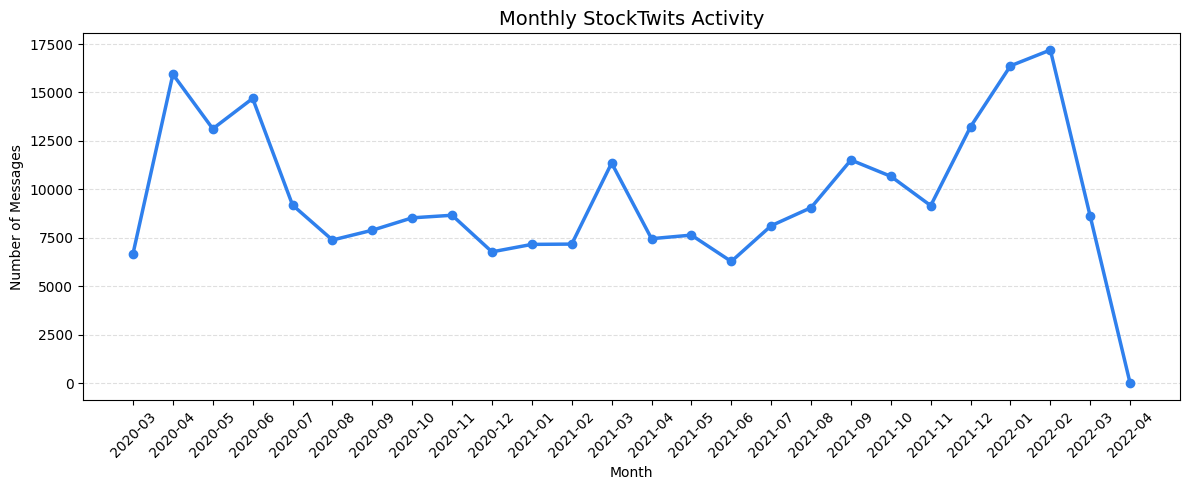

In [ ]:
# Analysing monthly posting activity

analysis_df["Month"] = analysis_df["DateTime"].dt.to_period("M")

monthly_posts = (
    analysis_df.groupby("Month")
    .size()
    .reset_index(name="Messages")
)

monthly_posts["Month"] = monthly_posts["Month"].astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_posts["Month"],
    monthly_posts["Messages"],
    marker="o",
    linewidth=2.5,
    color="#2F80ED"
)

plt.xticks(rotation=45)

plt.title("Monthly StockTwits Activity", fontsize=14)

plt.xlabel("Month")

plt.ylabel("Number of Messages")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

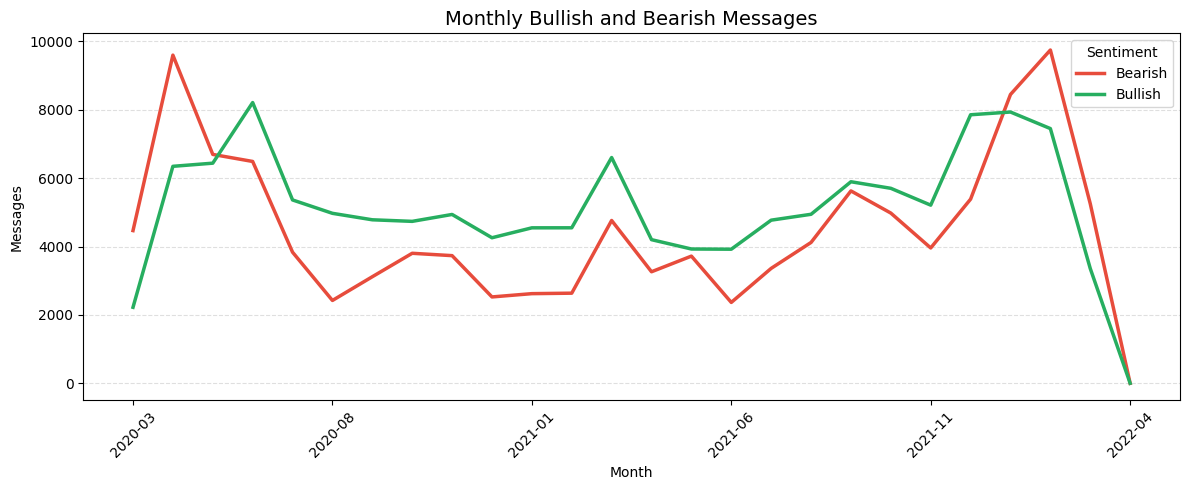

In [ ]:
# Comparing monthly bullish and bearish discussions

monthly_sentiment = (
    analysis_df.groupby(
        [
            analysis_df["DateTime"].dt.to_period("M"),
            "Sentiment"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

monthly_sentiment.index = monthly_sentiment.index.astype(str)

monthly_sentiment.plot(
    figsize=(12,5),
    color=["#E74C3C", "#27AE60"],
    linewidth=2.5
)

plt.title("Monthly Bullish and Bearish Messages", fontsize=14)

plt.xlabel("Month")

plt.ylabel("Messages")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

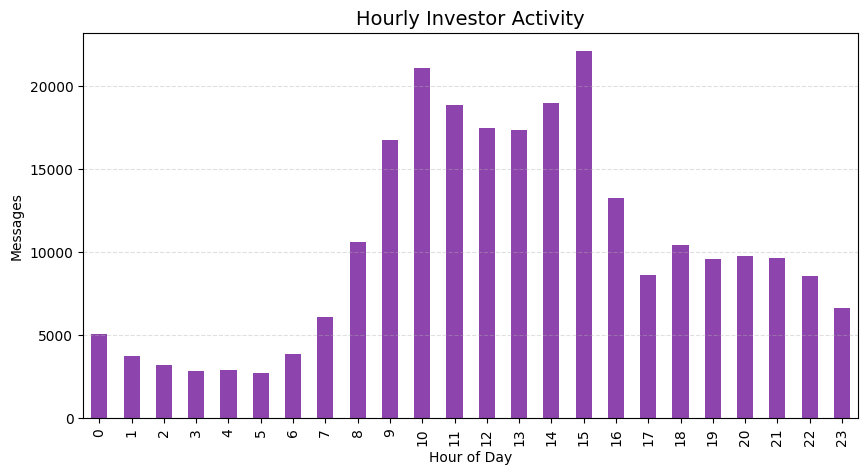

In [ ]:
# Analysing investor activity throughout the day

analysis_df["Hour"] = analysis_df["DateTime"].dt.hour

hourly_activity = analysis_df.groupby("Hour").size()

plt.figure(figsize=(10,5))

hourly_activity.plot(
    kind="bar",
    color="#8E44AD"
)

plt.title("Hourly Investor Activity", fontsize=14)

plt.xlabel("Hour of Day")

plt.ylabel("Messages")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

In [ ]:
# Calculating message length

analysis_df["Character_Count"] = analysis_df["Sentence"].str.len()

analysis_df["Word_Count"] = analysis_df["Sentence"].str.split().str.len()

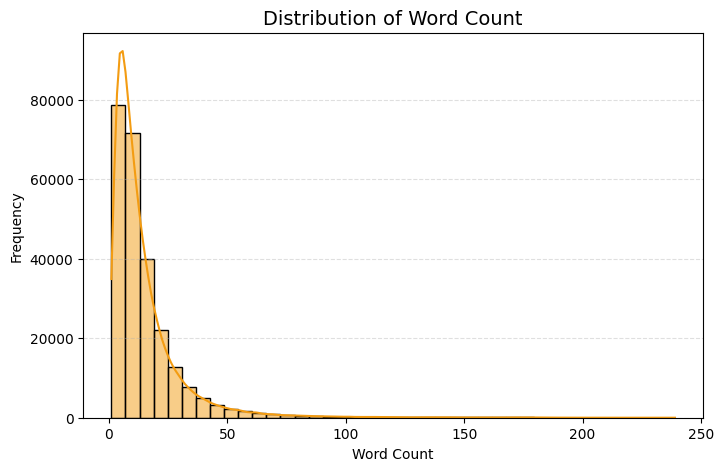

In [ ]:
# Visualising the word count distribution

plt.figure(figsize=(8,5))

sns.histplot(
    analysis_df["Word_Count"],
    bins=40,
    kde=True,
    color="#F39C12"
)

plt.title("Distribution of Word Count", fontsize=14)

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

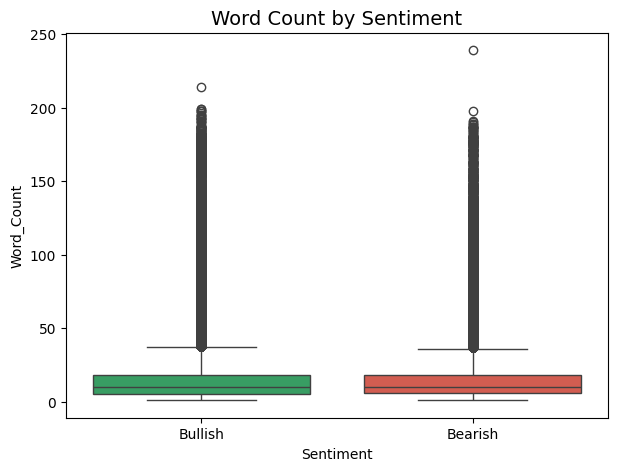

In [ ]:
# Comparing message length across sentiment classes

plt.figure(figsize=(7,5))

sns.boxplot(
    data=analysis_df,
    x="Sentiment",
    y="Word_Count",
    palette={
        "Bullish":"#27AE60",
        "Bearish":"#E74C3C"
    }
)

plt.title("Word Count by Sentiment", fontsize=14)

plt.show()

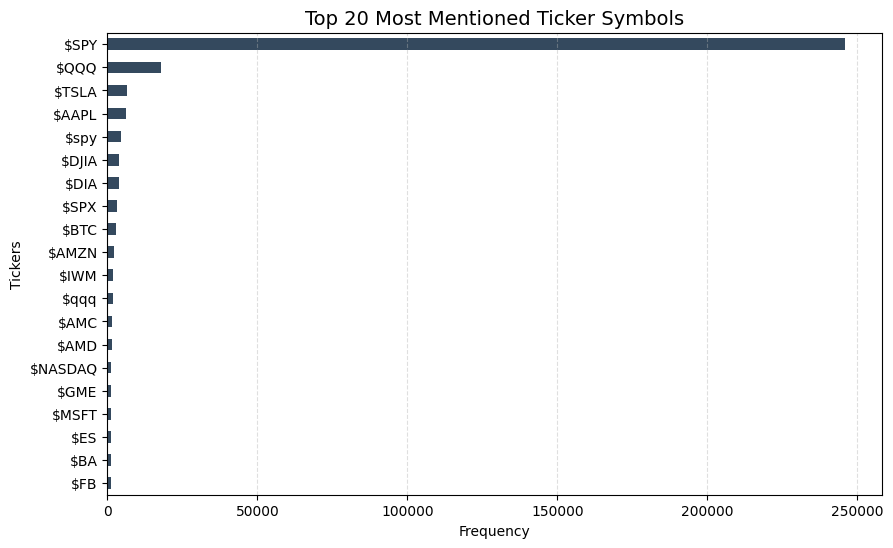

In [ ]:
# Extracting ticker symbols

analysis_df["Tickers"] = analysis_df["Sentence"].str.findall(r"\$[A-Za-z]+")

all_tickers = (
    analysis_df["Tickers"]
    .explode()
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,6))

all_tickers.sort_values().plot(
    kind="barh",
    color="#34495E"
)

plt.title("Top 20 Most Mentioned Ticker Symbols", fontsize=14)

plt.xlabel("Frequency")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

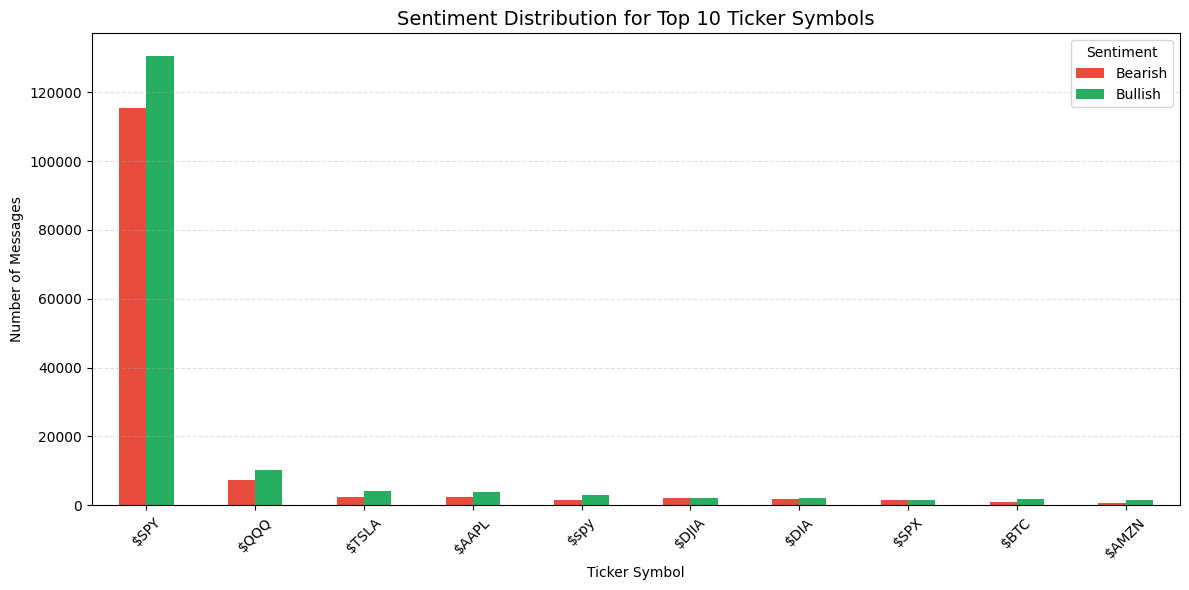

In [ ]:
# Analysing sentiment for the most frequently mentioned ticker symbols

ticker_sentiment = (
    analysis_df
    .explode("Tickers")
    .groupby(["Tickers", "Sentiment"])
    .size()
    .unstack(fill_value=0)
)

top10 = all_tickers.head(10).index

ticker_sentiment.loc[top10].plot(
    kind="bar",
    figsize=(12,6),
    color=["#E74C3C","#27AE60"]
)

plt.title("Sentiment Distribution for Top 10 Ticker Symbols", fontsize=14)

plt.xlabel("Ticker Symbol")

plt.ylabel("Number of Messages")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [ ]:
# Creating English stopwords

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [ ]:
# Defining the text cleaning function

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"\$[a-zA-Z]+", "", text)

    text = re.sub(r"[^a-z\s]", " ", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
        and len(word) > 2
    ]

    return words

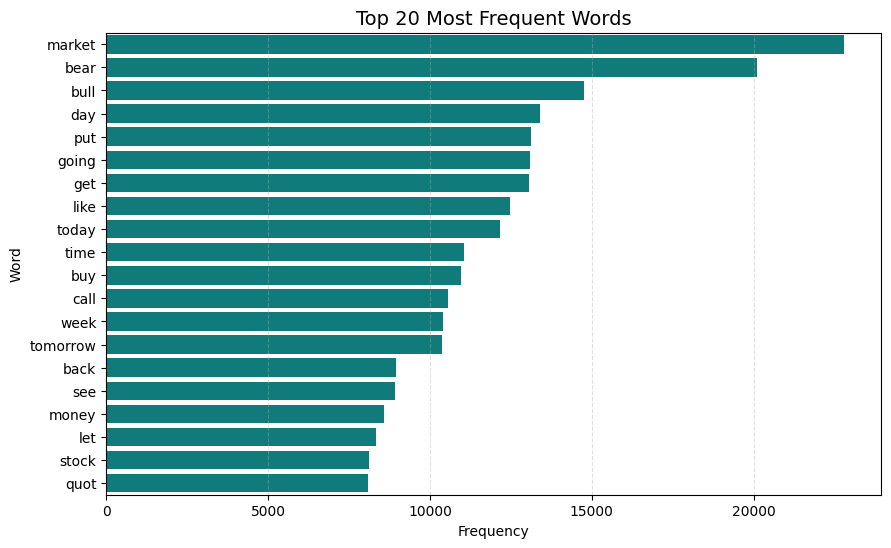

In [ ]:
# Identifying the most frequent words

all_words = []

for sentence in analysis_df["Sentence"]:
    all_words.extend(clean_text(sentence))

word_counts = Counter(all_words)

top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word","Frequency"]
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words,
    y="Word",
    x="Frequency",
    color="#008B8B"
)

plt.title("Top 20 Most Frequent Words", fontsize=14)

plt.xlabel("Frequency")

plt.ylabel("Word")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

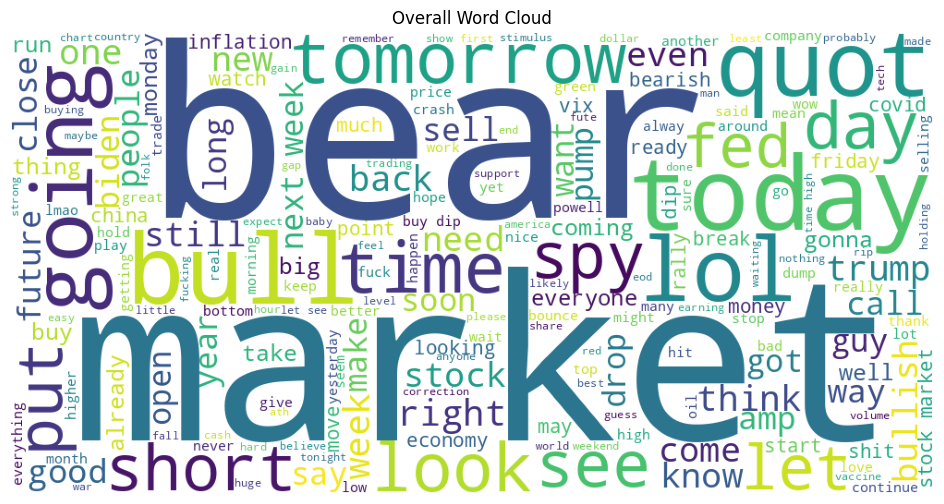

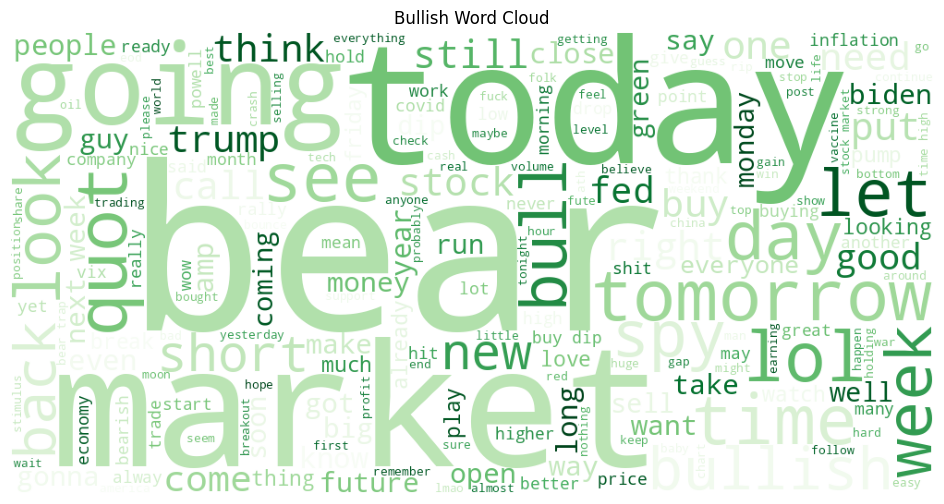

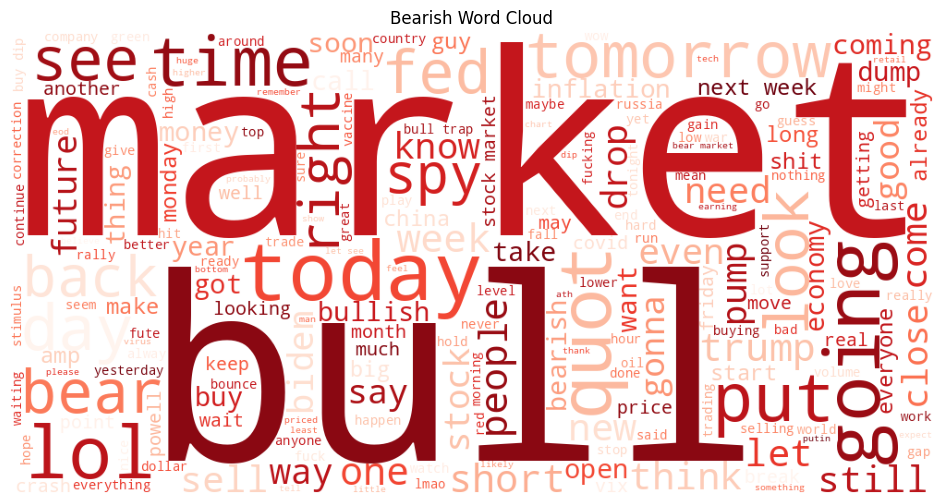

In [ ]:
# Creating the overall word cloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
).generate(" ".join(all_words))

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Overall Word Cloud")

plt.show()

# Creating the bullish word cloud

bullish_words = []

for sentence in analysis_df.loc[
    analysis_df["Sentiment"]=="Bullish",
    "Sentence"
]:
    bullish_words.extend(clean_text(sentence))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Greens"
).generate(" ".join(bullish_words))

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Bullish Word Cloud")

plt.show()

# Creating the bearish word cloud

bearish_words = []

for sentence in analysis_df.loc[
    analysis_df["Sentiment"]=="Bearish",
    "Sentence"
]:
    bearish_words.extend(clean_text(sentence))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Reds"
).generate(" ".join(bearish_words))

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Bearish Word Cloud")

plt.show()

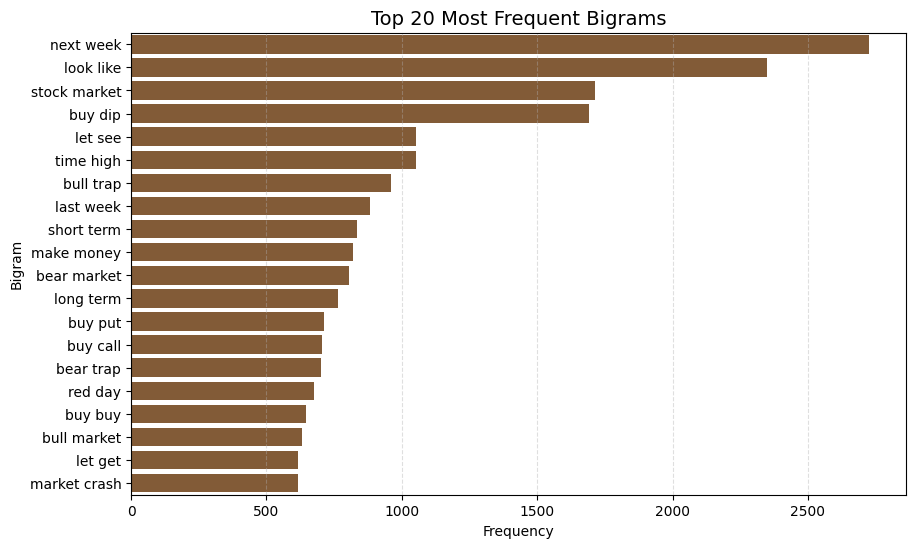

In [ ]:
# Identifying the most frequent bigrams
analysis_df["Clean_Text"] = analysis_df["Sentence"].apply(
    lambda x: " ".join(clean_text(x))
)
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(analysis_df["Clean_Text"])

bigram_df = pd.DataFrame({
    "Bigram": vectorizer.get_feature_names_out(),
    "Frequency": X.sum(axis=0).A1
})

bigram_df = bigram_df.sort_values(
    by="Frequency",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_df,
    y="Bigram",
    x="Frequency",
    color="#8E5A2B"
)

plt.title("Top 20 Most Frequent Bigrams", fontsize=14)

plt.xlabel("Frequency")

plt.ylabel("Bigram")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

# Text Preprocessing

In [ ]:
# Creating a copy of the analysis dataset

model_df = analysis_df.copy()

In [ ]:
# Selecting the required columns

model_df = model_df[
    ["Sentence", "Sentiment"]
]

model_df.head()

,Sentence,Sentiment
1073644,$SPY Ha ha 😇🤣🧞‍♂️🗞. \n\nhttps://apple.news/AP...,Bullish
213804,$SPY Dig them CALLS out Bulls🤭😬.... After toda...,Bearish
639589,$SPY $QQQ anyone who cant read this manipulati...,Bullish
641927,$SPY ...,Bullish
99663,$SPY The protests will eventually turn to riot...,Bearish


In [ ]:
# Encoding the sentiment labels

model_df["Sentiment"] = model_df["Sentiment"].map(
    {
        "Bearish": 0,
        "Bullish": 1
    }
)

model_df["Sentiment"].value_counts()

,count
Sentiment,
1,133097
0,116903


In [ ]:
# Defining the text preprocessing function

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"\$[A-Za-z]+", " ", text)

    text = re.sub(r"[^a-z\s]", " ", text)

    text = re.sub(r"\d+", " ", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
        and len(word) > 2
    ]

    return " ".join(words)

In [ ]:
# Applying text preprocessing

model_df["Processed_Text"] = model_df["Sentence"].apply(
    preprocess_text
)

model_df.head()

,Sentence,Sentiment,Processed_Text
1073644,$SPY Ha ha 😇🤣🧞‍♂️🗞. \n\nhttps://apple.news/AP...,1,
213804,$SPY Dig them CALLS out Bulls🤭😬.... After toda...,0,dig call bull today disappointment supreme fra...
639589,$SPY $QQQ anyone who cant read this manipulati...,1,anyone cant read manipulation shouldnt even ea...
641927,$SPY ...,1,
99663,$SPY The protests will eventually turn to riot...,0,protest eventually turn riot georgia lockdown ...


In [ ]:
# Comparing the original and processed text

comparison_df = model_df[
    ["Sentence", "Processed_Text"]
].sample(5, random_state=RANDOM_STATE)

comparison_df

,Sentence,Processed_Text
181740,$SPY if those AE and PM dogs bring this back t...,dog bring back tomorrow ill waiting pounce mar...
728116,$SPY Going to follow the same strategy as yest...,going follow strategy yesterday scalp call opt...
2518,"$SPY oh man, VOL starting to pick up, stick a ...",man vol starting pick stick fork
1190618,$SPY Has to tag 463 before we start grinding b...,tag start grinding back
45650,$SPY in and out all day,day


In [ ]:
# Checking for missing values

model_df.isnull().sum()

,0
Sentence,0
Sentiment,0
Processed_Text,0


In [ ]:
# Checking duplicate processed messages

duplicate_processed = model_df.duplicated(
    subset="Processed_Text"
).sum()

print(f"Duplicate Processed Messages : {duplicate_processed:,}")

Duplicate Processed Messages : 43,655


In [ ]:
# Displaying the processed dataset information

model_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250000 entries, 1073644 to 1248407
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Sentence        250000 non-null  object
 1   Sentiment       250000 non-null  int64 
 2   Processed_Text  250000 non-null  object
dtypes: int64(1), object(2)
memory usage: 7.6+ MB


In [ ]:
# Displaying the final processed dataset

model_df.head()

,Sentence,Sentiment,Processed_Text
1073644,$SPY Ha ha 😇🤣🧞‍♂️🗞. \n\nhttps://apple.news/AP...,1,
213804,$SPY Dig them CALLS out Bulls🤭😬.... After toda...,0,dig call bull today disappointment supreme fra...
639589,$SPY $QQQ anyone who cant read this manipulati...,1,anyone cant read manipulation shouldnt even ea...
641927,$SPY ...,1,
99663,$SPY The protests will eventually turn to riot...,0,protest eventually turn riot georgia lockdown ...


# Feature Engineering using TF-IDF

In [ ]:
# Creating TF-IDF features from the processed text

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.95
)

X = tfidf.fit_transform(model_df["Processed_Text"])

y = model_df["Sentiment"]

In [ ]:
# Displaying the shape of the TF-IDF matrix

print(f"Feature Matrix Shape : {X.shape}")

Feature Matrix Shape : (250000, 5000)


In [ ]:
# Displaying the number of extracted features

print(f"Total Features : {len(tfidf.get_feature_names_out())}")

Total Features : 5000


In [ ]:
# Displaying the first 30 extracted features

feature_names = tfidf.get_feature_names_out()

feature_names[:30]

array(['aabb', 'aapl', 'ability', 'able', 'absolute', 'absolutely',
       'absurd', 'accelerate', 'accept', 'access', 'access wider',
       'according', 'accordingly', 'account', 'accumulate',
       'accumulating', 'accumulation', 'accurate', 'ackman', 'across',
       'across board', 'act', 'act like', 'acting', 'acting like',
       'action', 'active', 'activity', 'actual', 'actually'], dtype=object)

In [ ]:
# Displaying a random sample of extracted features

pd.Series(feature_names).sample(
    20,
    random_state=RANDOM_STATE
)

,0
987,cramer
254,banking
3013,next couple
784,china virus
188,ath
2659,making
787,choice
897,confidence
125,another week
4956,wsb


In [ ]:
# Displaying a small portion of the TF-IDF matrix

tfidf_preview = pd.DataFrame(
    X[:5, :10].toarray(),
    columns=feature_names[:10]
)

tfidf_preview

,aabb,aapl,ability,able,absolute,absolutely,absurd,accelerate,accept,access
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Calculating the average TF-IDF score of each feature

mean_scores = np.asarray(
    X.mean(axis=0)
).ravel()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Average TF-IDF": mean_scores
})

feature_importance = feature_importance.sort_values(
    by="Average TF-IDF",
    ascending=False
)

feature_importance.head(20)

,Feature,Average TF-IDF
275,bear,0.019156
2688,market,0.014616
557,bull,0.014523
3492,put,0.012750
4501,today,0.011880
4531,tomorrow,0.011723
1841,going,0.011252
1063,day,0.010886
1777,get,0.010761
655,call,0.010376


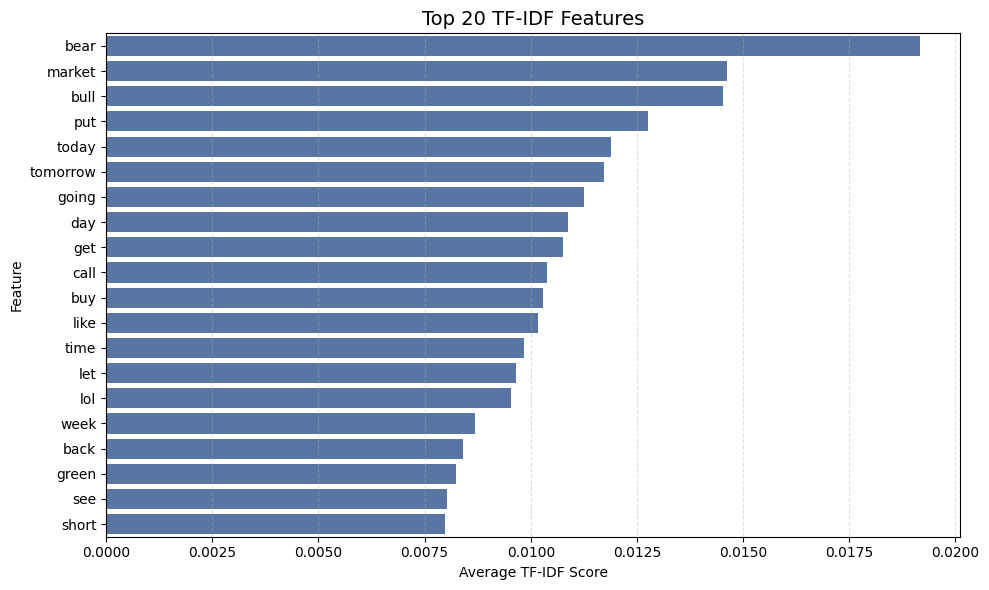

In [ ]:
# Visualising the highest average TF-IDF features

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(20),
    y="Feature",
    x="Average TF-IDF",
    color="#4C72B0"
)

plt.title("Top 20 TF-IDF Features", fontsize=14)

plt.xlabel("Average TF-IDF Score")

plt.ylabel("Feature")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [ ]:
# Calculating the sparsity of the TF-IDF matrix

sparsity = (
    1 - X.count_nonzero() /
    (X.shape[0] * X.shape[1])
)

print(f"Matrix Sparsity : {sparsity:.2%}")

Matrix Sparsity : 99.86%


# Train-Test Split

In [ ]:
# Splitting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

In [ ]:
# Displaying the training and testing dataset sizes

print(f"Training Samples : {X_train.shape[0]:,}")
print(f"Testing Samples  : {X_test.shape[0]:,}")

Training Samples : 200,000
Testing Samples  : 50,000


In [ ]:
# Displaying the feature matrix dimensions

print(f"Training Feature Matrix : {X_train.shape}")
print(f"Testing Feature Matrix  : {X_test.shape}")

Training Feature Matrix : (200000, 5000)
Testing Feature Matrix  : (50000, 5000)


In [ ]:
# Displaying the class distribution

train_distribution = (
    y_train
    .value_counts(normalize=True)
    .rename("Training")
    * 100
)

test_distribution = (
    y_test
    .value_counts(normalize=True)
    .rename("Testing")
    * 100
)

distribution_df = pd.concat(
    [train_distribution, test_distribution],
    axis=1
)

distribution_df

,Training,Testing
Sentiment,,
1,53.239,53.238
0,46.761,46.762


# Baseline Model Development


Model 1: Logistic Regression

In [ ]:
# Training the Logistic Regression model

lr_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=38)

In [ ]:
# Generating predictions using Logistic Regression

lr_predictions = lr_model.predict(X_test)

In [ ]:
# Calculating the evaluation metrics

lr_accuracy = accuracy_score(y_test, lr_predictions)

lr_precision = precision_score(y_test, lr_predictions)

lr_recall = recall_score(y_test, lr_predictions)

lr_f1 = f1_score(y_test, lr_predictions)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

Accuracy : 0.6957
Precision: 0.6915
Recall   : 0.7735
F1 Score : 0.7302


In [ ]:
# Displaying the classification report

print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=["Bearish","Bullish"]
    )
)

              precision    recall  f1-score   support

     Bearish       0.70      0.61      0.65     23381
     Bullish       0.69      0.77      0.73     26619

    accuracy                           0.70     50000
   macro avg       0.70      0.69      0.69     50000
weighted avg       0.70      0.70      0.69     50000



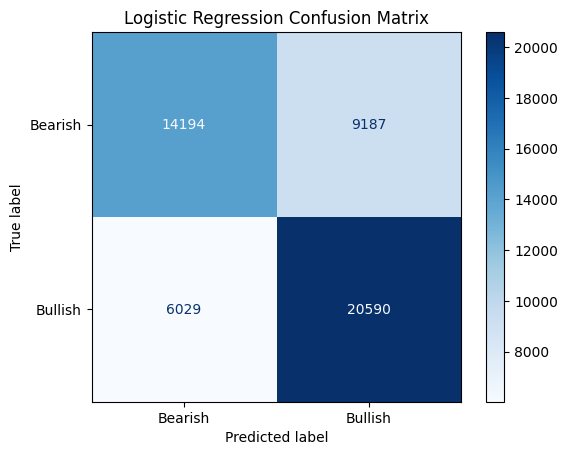

In [ ]:
# Displaying the confusion matrix

cm = confusion_matrix(
    y_test,
    lr_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Bearish","Bullish"]
).plot(
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.grid(False)

plt.show()

Model 2: Multinomial Naive Bayes

In [ ]:
# Training the Multinomial Naive Bayes model

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
# Generating predictions using Multinomial Naive Bayes

nb_predictions = nb_model.predict(X_test)

In [ ]:
# Calculating the evaluation metrics

nb_accuracy = accuracy_score(y_test, nb_predictions)

nb_precision = precision_score(y_test, nb_predictions)

nb_recall = recall_score(y_test, nb_predictions)

nb_f1 = f1_score(y_test, nb_predictions)

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")

Accuracy : 0.6835
Precision: 0.6736
Recall   : 0.7867
F1 Score : 0.7257


In [ ]:
# Displaying the classification report

print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=["Bearish", "Bullish"]
    )
)

              precision    recall  f1-score   support

     Bearish       0.70      0.57      0.63     23381
     Bullish       0.67      0.79      0.73     26619

    accuracy                           0.68     50000
   macro avg       0.69      0.68      0.68     50000
weighted avg       0.69      0.68      0.68     50000



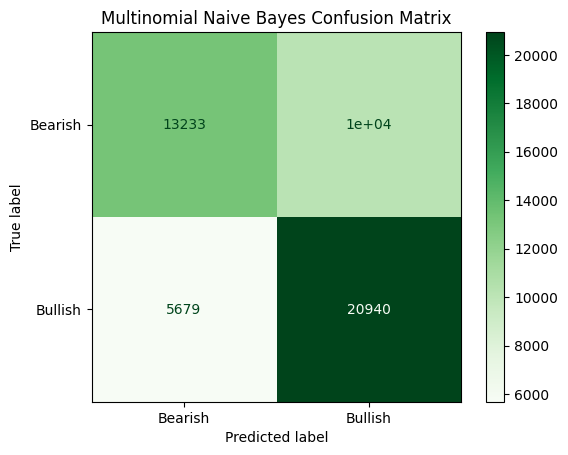

In [ ]:
# Displaying the confusion matrix

cm = confusion_matrix(
    y_test,
    nb_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Bearish", "Bullish"]
).plot(
    cmap="Greens"
)

plt.title("Multinomial Naive Bayes Confusion Matrix")

plt.grid(False)

plt.show()

Model 3: Linear Support Vector Machine

In [ ]:
# Training the Linear Support Vector Machine model

svm_model = LinearSVC(
    random_state=RANDOM_STATE
)

svm_model.fit(X_train, y_train)

LinearSVC(random_state=38)

In [ ]:
# Generating predictions using Linear SVC

svm_predictions = svm_model.predict(X_test)

In [ ]:
# Calculating the evaluation metrics

svm_accuracy = accuracy_score(y_test, svm_predictions)

svm_precision = precision_score(y_test, svm_predictions)

svm_recall = recall_score(y_test, svm_predictions)

svm_f1 = f1_score(y_test, svm_predictions)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")

Accuracy : 0.6921
Precision: 0.6885
Recall   : 0.7698
F1 Score : 0.7269


In [ ]:
# Displaying the classification report

print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=["Bearish", "Bullish"]
    )
)

              precision    recall  f1-score   support

     Bearish       0.70      0.60      0.65     23381
     Bullish       0.69      0.77      0.73     26619

    accuracy                           0.69     50000
   macro avg       0.69      0.69      0.69     50000
weighted avg       0.69      0.69      0.69     50000



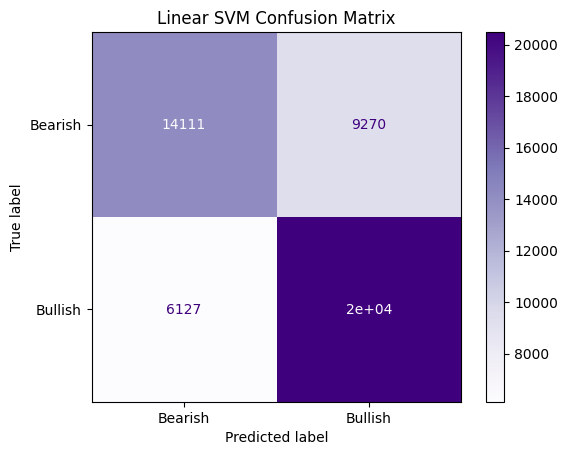

In [ ]:
# Displaying the confusion matrix

cm = confusion_matrix(
    y_test,
    svm_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Bearish", "Bullish"]
).plot(
    cmap="Purples"
)

plt.title("Linear SVM Confusion Matrix")

plt.grid(False)

plt.show()

Model 4: Random Forest

In [ ]:
# Training the Random Forest classifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    min_samples_split=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=50,
                       n_jobs=-1, random_state=38)

In [ ]:
# Generating predictions using Random Forest

rf_predictions = rf_model.predict(X_test)

In [ ]:
# Calculating the evaluation metrics

rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_precision = precision_score(y_test, rf_predictions)

rf_recall = recall_score(y_test, rf_predictions)

rf_f1 = f1_score(y_test, rf_predictions)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Accuracy : 0.6202
Precision: 0.5908
Recall   : 0.9322
F1 Score : 0.7232


In [ ]:
# Displaying the classification report

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Bearish", "Bullish"]
    )
)

              precision    recall  f1-score   support

     Bearish       0.77      0.26      0.39     23381
     Bullish       0.59      0.93      0.72     26619

    accuracy                           0.62     50000
   macro avg       0.68      0.60      0.56     50000
weighted avg       0.68      0.62      0.57     50000



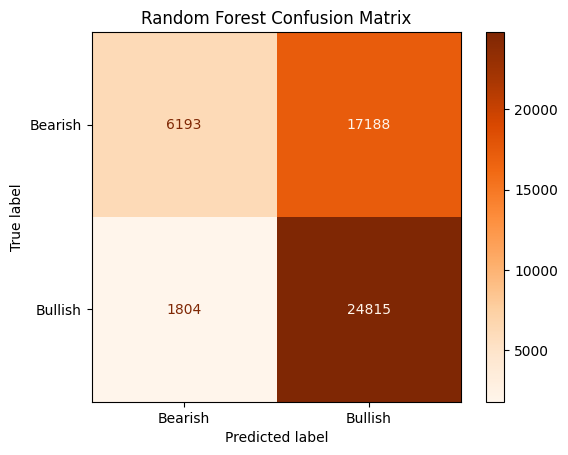

In [ ]:
# Displaying the confusion matrix

cm = confusion_matrix(
    y_test,
    rf_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Bearish", "Bullish"]
).plot(
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")

plt.grid(False)

plt.show()

# Model Comparison

In [ ]:
# Creating the model comparison table

results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy,
        rf_accuracy
    ],

    "Precision": [
        lr_precision,
        nb_precision,
        svm_precision,
        rf_precision
    ],

    "Recall": [
        lr_recall,
        nb_recall,
        svm_recall,
        rf_recall
    ],

    "F1 Score": [
        lr_f1,
        nb_f1,
        svm_f1,
        rf_f1
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.69568,0.691473,0.773508,0.730194
1,Multinomial Naive Bayes,0.68346,0.673572,0.786656,0.725735
2,Linear SVM,0.69206,0.688529,0.769826,0.726912
3,Random Forest,0.62016,0.590791,0.932229,0.723237


In [ ]:
# Ranking the models based on F1 Score and Accuracy

results = results.sort_values(
    by=["F1 Score", "Accuracy"],
    ascending=False
).reset_index(drop=True)

results.insert(
    0,
    "Rank",
    range(1, len(results) + 1)
)

results

,Rank,Model,Accuracy,Precision,Recall,F1 Score
0,1,Logistic Regression,0.69568,0.691473,0.773508,0.730194
1,2,Linear SVM,0.69206,0.688529,0.769826,0.726912
2,3,Multinomial Naive Bayes,0.68346,0.673572,0.786656,0.725735
3,4,Random Forest,0.62016,0.590791,0.932229,0.723237


In [ ]:
# Displaying the best-performing model

best_model = results.iloc[0]

print("Best Performing Model")
print("-" * 40)
print(best_model)

Best Performing Model
----------------------------------------
Rank                           1
Model        Logistic Regression
Accuracy                 0.69568
Precision               0.691473
Recall                  0.773508
F1 Score                0.730194
Name: 0, dtype: object


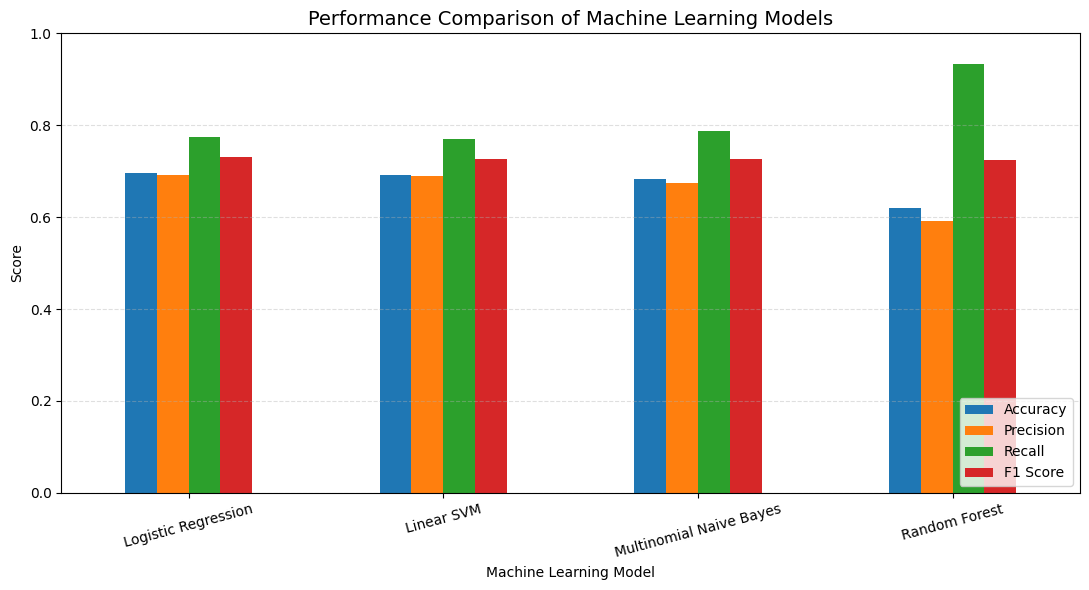

In [ ]:
# Visualising the model performance

results_plot = results.set_index("Model")

results_plot[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(11,6)
)

plt.title("Performance Comparison of Machine Learning Models", fontsize=14)

plt.ylabel("Score")

plt.xlabel("Machine Learning Model")

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=15)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

# Hyperparameter Tuning using GridSearchCV

In [ ]:
# Defining the hyperparameter search space

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

In [ ]:
# Performing hyperparameter tuning using GridSearchCV

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=38),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [ ]:
# Displaying the optimal hyperparameters

print("Best Parameters:")
print(grid_search.best_params_)

print()

print(f"Best Cross Validation F1 Score : {grid_search.best_score_:.4f}")

Best Parameters:
{'C': 0.1, 'solver': 'liblinear'}

Best Cross Validation F1 Score : 0.7270


In [ ]:
# Retrieving the best Logistic Regression model

best_lr = grid_search.best_estimator_

In [ ]:
# Generating predictions using the tuned model

best_predictions = best_lr.predict(X_test)

In [ ]:
# Calculating the evaluation metrics

best_accuracy = accuracy_score(y_test, best_predictions)

best_precision = precision_score(y_test, best_predictions)

best_recall = recall_score(y_test, best_predictions)

best_f1 = f1_score(y_test, best_predictions)

print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1 Score : {best_f1:.4f}")

Accuracy : 0.6922
Precision: 0.6845
Recall   : 0.7826
F1 Score : 0.7303


In [ ]:
# Displaying the classification report

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Bearish", "Bullish"]
    )
)

              precision    recall  f1-score   support

     Bearish       0.70      0.59      0.64     23381
     Bullish       0.68      0.78      0.73     26619

    accuracy                           0.69     50000
   macro avg       0.69      0.69      0.69     50000
weighted avg       0.69      0.69      0.69     50000



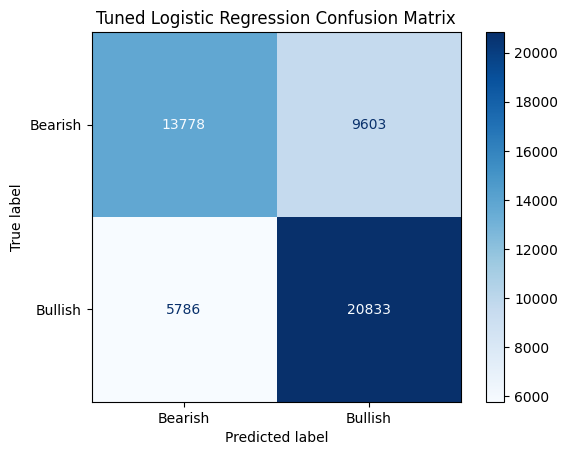

In [ ]:
# Displaying the confusion matrix

cm = confusion_matrix(
    y_test,
    best_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Bearish", "Bullish"]
).plot(
    cmap="Blues"
)

plt.title("Tuned Logistic Regression Confusion Matrix")

plt.grid(False)

plt.show()

In [ ]:
# Comparing the baseline and tuned Logistic Regression models

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Baseline":[
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ],

    "Tuned":[
        best_accuracy,
        best_precision,
        best_recall,
        best_f1
    ]

})

comparison["Difference"] = (
    comparison["Tuned"] -
    comparison["Baseline"]
).round(4)

comparison

,Metric,Baseline,Tuned,Difference
0,Accuracy,0.695680,0.692220,-0.0035
1,Precision,0.691473,0.684485,-0.0070
2,Recall,0.773508,0.782636,0.0091
3,F1 Score,0.730194,0.730278,0.0001


In [ ]:
import joblib

joblib.dump(best_model, "logistic_regression_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


In [ ]:
import os

print(os.path.exists("logistic_regression_model.pkl"))
print(os.path.exists("tfidf_vectorizer.pkl"))

True
True


In [ ]:
import joblib

# Load saved model and vectorizer
model = joblib.load("logistic_regression_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Model loaded:", type(model))
print("Vectorizer loaded:", type(vectorizer))

Model loaded: <class 'pandas.core.series.Series'>
Vectorizer loaded: <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
